# Approximation of CEF via flexible functional form

The least squares parameter provides the best linear predictor of the conditional expectation function (CEF) $E[Y|X]$ in the sense of mean square error. If the actual CEF is linear, OLS will perfectly coincide with it; if it is non-linear, least squares offers the best linear approximation. However, if the CEF is suspected to be significantly non-linear, one can better approximate it by replacing the original variables with a sufficiently large dictionary of transformed variables $P(X)$, often called technical regressors.

For a continuous, one-dimensional variable (typically scaled to take values between 0 and 1), standard dictionaries include:
- Polynomial dictionary $P(X) = [1, X, X^2, X^3]$
- Cosine dictionary $P(X) = [1, X, \cos(\pi*X), \cos(2*\pi*X)]$
- Linear (and quadratic) spline dictionaries $P(X) = [1, X, \max(0, X-k_1), \max(X-k_2)]$
- Local linear (and local quadratic) partition dictionaries $P(X) = [I_1(X), X*I_1(X), I_2(X), (X-k1)*I_2(X)]$ for $I_j = 1(k_{j-1}< X \leq k_j)$

If the data has multiple dimensions, dictionaries are first created for each individual component and then combined into a joint dictionary by multiplying the terms from the individual dictionaries together. Under mild regularity conditions, if the CEF is smooth, the error of the approximation shrinks to zero as the size of the dictionary approaches infinity.

Below an illustration of how small dictionaries can provide approximations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

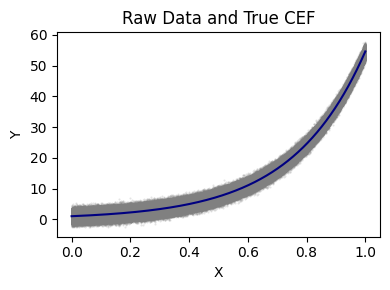

In [2]:
# Generate the true CEF

X_grid = np.linspace(0, 1, 1000)
CEF_grid = np.exp(4 * X_grid)  # True CEF

# Generate a random dataset

np.random.seed(42)
N = 1000000  # Sample size 10^6
X = np.random.uniform(0, 1, N)
# Y is the true CEF plus standard normal noise
Y = np.exp(4 * X) + np.random.normal(0, 1, N)

# Plot the raw data
plt.figure(figsize=(4, 3))
plt.plot(X_grid, CEF_grid, label='CEF', color='navy', linewidth=1.5)
plt.scatter(X, Y, label='Y', color='grey', marker='.', alpha=0.2, s=1)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Raw Data and True CEF')
plt.tight_layout()
plt.show()

In [3]:
# Define the dictionaries
def get_polynomial_features(x, power = 3):
    # P(X) = [1, X, X^2, X^3]
    return np.column_stack([np.ones_like(x), *[x**p for p in range(1, power + 1)]])

def get_cosine_features(x, modes=2):
    # P(X) = [1, X, cos(pi*X), cos(2*pi*X)]
    return np.column_stack([np.ones_like(x), x, *[np.cos(m * np.pi * x) for m in range(1, modes + 1)]])

def get_spline_features(x, knots=[0.33, 0.67], power=1):
    # linear: P(X) = [1, X, max(0, X-knots[0]), max(0, X-knots[1])]
    return np.column_stack([
        np.ones_like(x), 
        *[x**p for p in range(1, power + 1)], 
        np.maximum(0, x - knots[0])**power, 
        np.maximum(0, x - knots[1])**power
    ])

def get_local_linear_features(x, k1=0.5):
    # P(X) = [I_1(X), X*I_1(X), I_2(X), (X-k1)*I_2(X)]
    k0 = 0
    k2 = 1
    I_1 = (x >= k0) & (x <= k1)
    I_2 = (x > k1) & (x <= k2)
    return np.column_stack([
        I_1.astype(float), 
        (x-k0) * I_1, 
        I_2.astype(float), 
        (x - k1) * I_2
    ])

In [4]:
# Fit models and predict using statsmodels

# Polynomial
poly_power = 4
mod_poly = sm.OLS(Y, get_polynomial_features(X, power=poly_power)).fit()
pred_poly = mod_poly.predict(get_polynomial_features(X_grid, power=poly_power))

# Cosine
cos_modes = 4
mod_cosine = sm.OLS(Y, get_cosine_features(X, modes=cos_modes)).fit()
pred_cosine = mod_cosine.predict(get_cosine_features(X_grid, modes=cos_modes))

# Linear Spline
knots = [0.4, 0.75]
power = 2
mod_spline = sm.OLS(Y, get_spline_features(X, knots=knots, power=power)).fit()
pred_spline = mod_spline.predict(get_spline_features(X_grid, knots=knots, power=power))

# Local Linear Partition
k1 = 0.6
mod_local = sm.OLS(Y, get_local_linear_features(X, k1=k1)).fit()
pred_local = mod_local.predict(get_local_linear_features(X_grid, k1=k1))

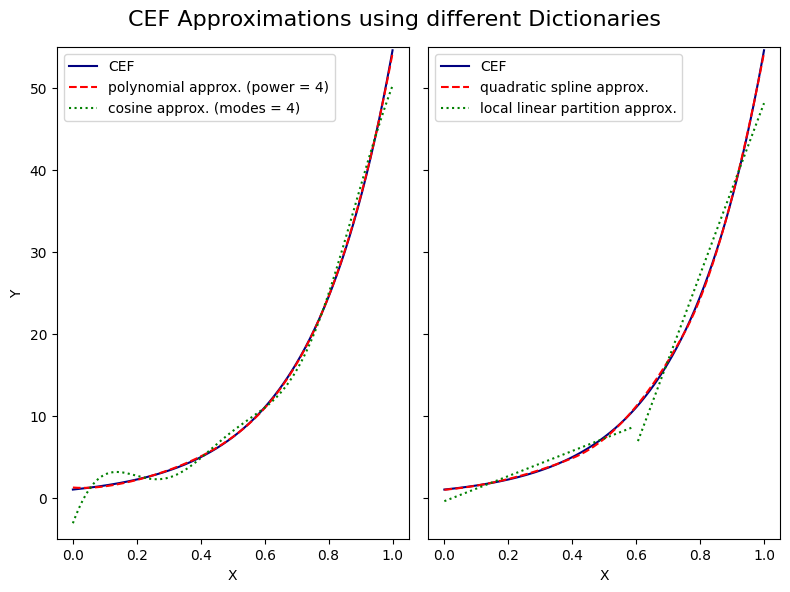

In [5]:
# Plot the results to match Figure 1.3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6), sharey=True)
plt.suptitle('CEF Approximations using different Dictionaries', fontsize=16)

# Left Subplot: Polynomial and Cosine
ax1.plot(X_grid, CEF_grid, label='CEF', color='navy', linewidth=1.5)
ax1.plot(X_grid, pred_poly, label="polynomial approx. (power = " + str(poly_power) + ")", color='red', linestyle='--')
ax1.plot(X_grid, pred_cosine, label='cosine approx. (modes = ' + str(cos_modes) + ')', color='green', linestyle=':')
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-5, 55)
ax1.legend(loc='upper left')

ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Right Subplot: Linear Spline and Local Linear Partition
pow_list = ["linear", "quadratic", "cubic", "quartic"]
ax2.plot(X_grid, CEF_grid, label='CEF', color='navy', linewidth=1.5)
ax2.plot(X_grid, pred_spline, label=pow_list[power-1] +' spline approx.', color='red', linestyle='--')

# To prevent the local partition line from connecting across the jump at x=k1, mask it with NaN
pred_local_masked = np.copy(pred_local)
pred_local_masked[np.abs(X_grid - k1) < 0.005] = np.nan 

ax2.plot(X_grid, pred_local_masked, label='local linear partition approx.', color='green', linestyle=':')
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-5, 55)
ax2.legend(loc='upper left')

ax2.set_xlabel('X')

plt.tight_layout()
plt.savefig('cef_approximations.png', dpi=300)
plt.show()